# Predictive Modeling of Monthly Honda Civic Sales 

This notebook performs predictive modeling of monthly Honda Civic sales using linear regression. It employs statistical techniques such as OLS regression, multicollinearity assessment via Variance Inflation Factor (VIF), and feature selection to build models with economic indicators (Unemployment, CivicQueries, CPIEnergy, CPIAll, MilesTraveled) and seasonal effects (MonthFactor). 

Machine learning practices include train-test splitting and out-of-sample evaluation using OSR2. Additional data engineering involves merging external gas price data to test new features. 

Libraries used: pandas for data manipulation, statsmodels for regression, scikit-learn for metrics, seaborn/matplotlib for visualization.



In [271]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.metrics import r2_score


#### Reading the dataset 

In [272]:
car_data= pd.read_csv('Civic-142A-Fall25.csv')
car_data

,MonthNumeric,MonthFactor,Year,CivicSales,Unemployment,CivicQueries,CPIAll,CPIEnergy,MilesTraveled
0,1,January,2014,21824,6.6,66,235.288,250.340,246531
1,2,February,2014,21575,6.7,69,235.547,249.925,249499
2,3,March,2014,27697,6.7,72,236.028,249.961,251120
3,4,April,2014,27611,6.2,69,236.468,249.864,251959
4,5,May,2014,36089,6.3,69,236.918,249.213,252289
...,...,...,...,...,...,...,...,...,...
122,3,March,2024,5664,3.8,87,312.230,287.399,273352
123,4,April,2024,5348,3.9,83,313.207,290.631,273430
124,5,May,2024,6700,4.0,88,313.225,284.742,274175
125,6,June,2024,5935,4.1,92,313.049,278.938,274160


### Spilting into Train and Test Datasets

In [273]:
## checking if there are months after july in 2024 
car_data[(car_data['MonthNumeric'] > 7) & (car_data['Year'] > 2024)]

,MonthNumeric,MonthFactor,Year,CivicSales,Unemployment,CivicQueries,CPIAll,CPIEnergy,MilesTraveled


In [274]:
#all observations from 2014 through 2019
train_data = car_data[(car_data['Year'] >= 2014) & (car_data['Year'] <= 2019)]
#all observations from jan 2020 through july 2024
test_data = car_data[(car_data['Year'] >= 2020) & (car_data['Year'] <= 2024)]

print(len(train_data), len(test_data))

72 55


#### Training the model with five independent variables Unemployment, CivicQueries, CPIEnergy, CPIAll and MilesTraveled.

In [275]:
ols = smf.ols(formula= 'CivicSales ~ Unemployment + CivicQueries + CPIEnergy + CPIAll + MilesTraveled', 
              data=train_data)
model1 =ols.fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     9.898
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           4.29e-07
Time:                        22:25:36   Log-Likelihood:                -687.82
No. Observations:                  72   AIC:                             1388.
Df Residuals:                      66   BIC:                             1401.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.298e+04   7.37e+04      0.176

From the results, looks like unemployment has a very high P score 



Selected a subset of these five variables and constructed a regression model to predict monthly Civic sales (CivicSales). Chose which of the five variables to use in order to build a high-quality linear regression
model. Used the training set to build my model, and did not add any additional variables
beyond the five indicated independent variables.

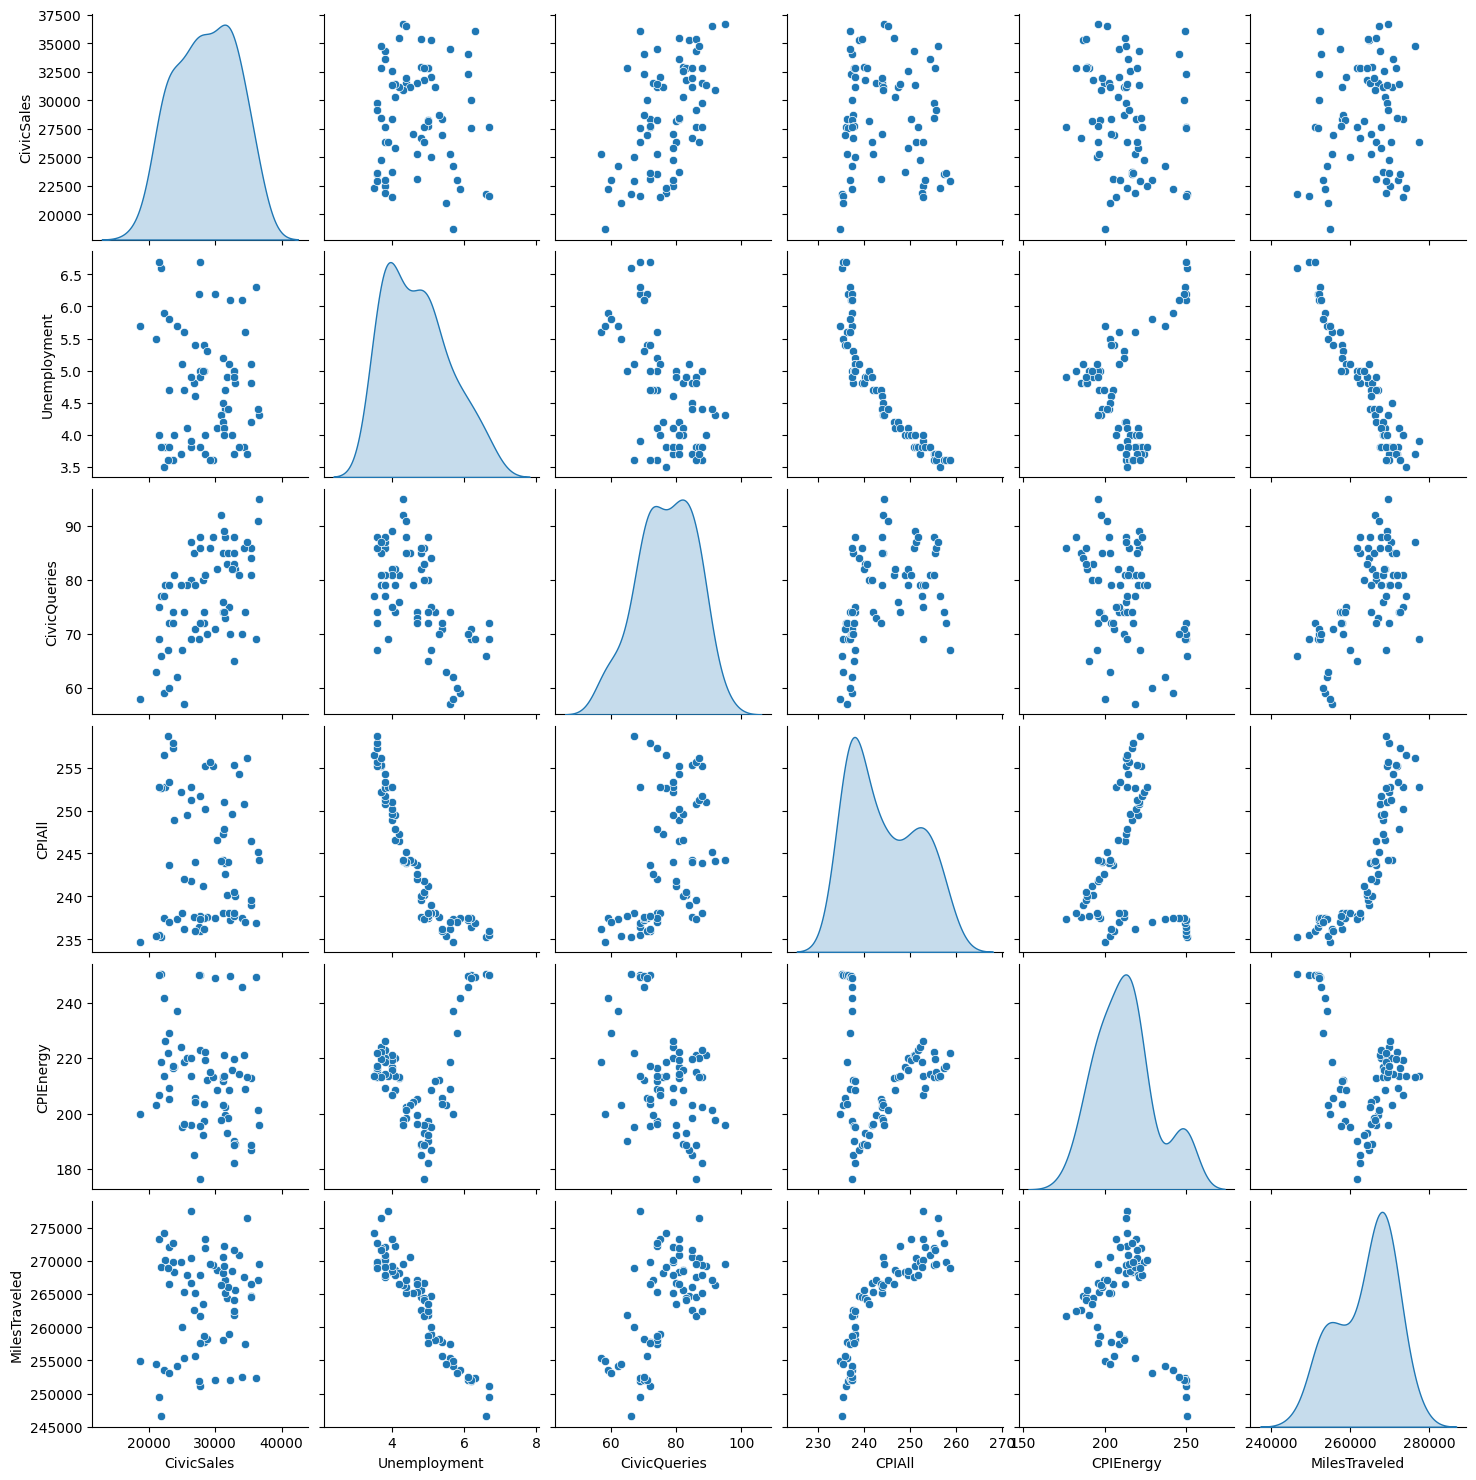

In [277]:
sns.pairplot(train_data.iloc[:,3:9],diag_kind='kde') # try diag_kind='kde' for kernel density estimate (represents the data using a continuous probability density curve )

From the plots

1. Unemployment has negative relationship with CPIALL and Miles travelled, so its a risk of multicollinearity. It also has a high p value meaning it isn't significant in regression.

2. CivicQuieres spread looks independent of other variables

3. CPIAll & MilesTraveled highly correlated

4. CPI energy has some patterns like CPIAll & MilesTraveled but not to extreme

### Testing the VIF for multilinearity

In [278]:
def VIF(df, columns):
    # The dataframe passed to VIF must include the intercept term. We add it the same way we did before.
    values = sm.add_constant(df[columns]).values
    num_columns = len(columns)+1
    vif = [variance_inflation_factor(values, i) for i in range(num_columns)]
    return pd.Series(vif[1:], index=columns)

cols = ['Unemployment', 'CivicQueries',  'CPIEnergy' , 'CPIAll' , 'MilesTraveled']
VIF(train_data, cols)

Unemployment     24.600912
CivicQueries      1.717734
CPIEnergy         5.033046
CPIAll           23.929349
MilesTraveled    12.647068
dtype: float64

Removing the biggest VIF which is Unemployment 

In [279]:
#remove unemployment
cols2 = ['CivicQueries' ,'CPIEnergy', 'CPIAll',  'MilesTraveled']

model2 = smf.ols(formula='CivicSales ~ CivicQueries + CPIEnergy + CPIAll + MilesTraveled',
                 data=train_data).fit()
print(model2.summary())

VIF(train_data, cols2)

                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     12.55
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           1.13e-07
Time:                        22:26:04   Log-Likelihood:                -687.84
No. Observations:                  72   AIC:                             1386.
Df Residuals:                      67   BIC:                             1397.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2.565e+04   2.22e+04      1.155

CivicQueries      1.683027
CPIEnergy         2.962402
CPIAll            9.720030
MilesTraveled    11.995681
dtype: float64

Miles Travelled and CPIAll are still high VIF, so we must remove one of them.

In [280]:
# removed CPIALL
cols3 = ['CivicQueries' ,'CPIEnergy','MilesTraveled'] 

model3 = smf.ols(formula='CivicSales ~ CivicQueries + CPIEnergy + MilesTraveled',
                 data=train_data).fit()

print(model3.summary())

VIF(train_data, cols3)

                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     12.45
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           1.39e-06
Time:                        22:26:05   Log-Likelihood:                -692.20
No. Observations:                  72   AIC:                             1392.
Df Residuals:                      68   BIC:                             1402.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      5.782e+04   2.04e+04      2.837

CivicQueries     1.677564
CPIEnergy        1.237736
MilesTraveled    1.627433
dtype: float64

In [281]:
# removed Miles Traveled
cols4 = ['CivicQueries','CPIEnergy', 'CPIAll' ]
model4 = smf.ols(formula='CivicSales ~ CivicQueries + CPIEnergy + CPIAll',
                 data=train_data).fit()

print(model4.summary())
VIF(train_data, cols4)

                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     15.40
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           9.51e-08
Time:                        22:26:05   Log-Likelihood:                -689.29
No. Observations:                  72   AIC:                             1387.
Df Residuals:                      68   BIC:                             1396.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     5.338e+04   1.49e+04      3.589   

CivicQueries    1.578403
CPIEnergy       1.290031
CPIAll          1.318700
dtype: float64

In [282]:
#add a linear combination



copy_of_train_data= train_data.copy()

copy_of_train_data['CPI_Miles'] = copy_of_train_data['CPIAll'] * copy_of_train_data['MilesTraveled']

cols5 = ['CivicQueries' ,'CPIEnergy','CPI_Miles'] 

model5 = smf.ols(formula='CivicSales ~ CivicQueries + CPIEnergy + CPI_Miles',
                 data=copy_of_train_data).fit()

print(cols5)
print(model5.summary())
print(VIF(copy_of_train_data, cols5))


print  (' ')
print  (' ')
print  (' ')

# apply log on the Miles Travelled

copy_of_train_data['log_MilesTraveled'] = np.log(copy_of_train_data['MilesTraveled'])
cols6 = ['CivicQueries','CPIEnergy', 'log_MilesTraveled' ]
model6 = smf.ols(formula='CivicSales ~ CivicQueries + CPIEnergy + log_MilesTraveled',
                 data=copy_of_train_data).fit()

print(cols6)
print(model6.summary())
print(VIF(copy_of_train_data, cols6))

print  (' ')
print  (' ')
print  (' ')

cols7 = ['CivicQueries','log_MilesTraveled', 'CPIAll' ]

model7 = smf.ols(formula='CivicSales ~ CivicQueries +  log_MilesTraveled + CPIAll',
                 data=copy_of_train_data).fit()

print(cols7)
print(model7.summary())
print(VIF(copy_of_train_data, cols7))


['CivicQueries', 'CPIEnergy', 'CPI_Miles']
                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     14.16
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           2.88e-07
Time:                        22:26:06   Log-Likelihood:                -690.49
No. Observations:                  72   AIC:                             1389.
Df Residuals:                      68   BIC:                             1398.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Inter

How I decided on the variables to use in the model and the quality of the linear regression model’s predictions, as evaluated using the training set 

- What is the linear regression equation produced by your model, and how should one
interpret the coefficients for the independent variables? Consider interpretability issues
when writing down the equation (e.g., do not just copy and paste the output from
Python).
- How did you select the variables to include in your linear regression model?
-Do the signs of the model’s coefficients make sense? Are you reasonably sure that the
signs are correct?
- How well does the model predict training set observations? Can you justify the model’s
performance on the training data with a quantifiable metric?

#### ANSWER
The final regression model using a subset of the 5 variables is:

$$
\text{CivicSales} \;=\; 53{,}380 
\;+\; 390.1(\text{CivicQueries}) 
\;+\; 28.1(\text{CPIEnergy}) 
\;-\; 248.9(\text{CPIAll})
$$

**Interpretation**

* CivicQueries:  When people search more for “Honda Civic” online, sales tend to go up. Each unit of search activity is linked to about 390 more Civics sold in a month. This makes sense, since more online interest usually reflects stronger consumer demand.

* CPIEnergy : Higher energy prices are linked to a slight increase in Civic sales; around 28 more cars for each unit increase in the energy index.

* CPIAll: When overall consumer prices rise, Civic sales drop. Each one-point increase in the overall CPI corresponds to about 249 fewer Civics sold. This is logical: as the cost of living rises, households are less likely to spend on large purchases like cars.

**Variable selection**

I began with all five predictors: Unemployment, CivicQueries, CPIEnergy, CPIAll, and MilesTraveled. I used methods like the pairplot to see the correlations and the VIF to see multi-linearity.

* Unemployment was dropped because it showed very weak statistical significance of p = 0.857
* MilesTraveled was very collinear with CPIAll with VIF of 11.9 and 9.7 respectively. 
* I tested combinations. Removing CPIAll reduced the R^2 to 0.355, while including CPIAll kept R² at 0.405 with all VIF values below 2, which shows acceptable multicollinearity.
* I also experimented with transformations (log MilesTraveled, linear combination of CPIAll and MilesTraveled), but these gave lower R^2 than the chosen subset.

So I decided to choose the subset CivicQueries, CPIEnergy, CPIAll with R^2 of .405 and all VIF values below 2. 


**Do the signs make sense?**
Yes they do, CivicQueries is positive because greater online searches or interest leads to higher sales. 

CPIAll is negative because higher inflation lead to lower sales. 

CPI energy is positive because higher energy prices may relate with stronger overall economic activity, so car sales also tend to rise. But this effect is statistically weaker, it should be interpreted with caution rather than taken as a firm causal relationship.

**Model performance**

The model has an R^2 of 0.405 and an Adjusted R^2 of 0.378 on the training data, meaning that roughly 40% of the variation in Civic sales is explained by the three predictors. It is not perfect model but the F-statistic is 15.40 and Prob(F-statistic), the overall model p-value is 0.001 which shows that the model as a whole is  statistically significantl, explaining more variance than chance.


In [283]:
# OLS results of my Model
print(model4.summary())


                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     15.40
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           9.51e-08
Time:                        22:26:07   Log-Likelihood:                -689.29
No. Observations:                  72   AIC:                             1387.
Df Residuals:                      68   BIC:                             1396.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     5.338e+04   1.49e+04      3.589   

Let us now try to further improve the linear regression model by modeling seasonality. In predicting demand and sales, seasonality is often very important since demand for most products tends to be periodic in time. For example, demand for heavy jackets and coats tends to be higher in the winter, while demand for sunscreen tends to be higher in the summer 

In [284]:
ols_s = smf.ols(formula= 'CivicSales ~ Unemployment + CivicQueries + CPIEnergy + CPIAll + MilesTraveled + MonthFactor', 
              data=train_data)
model_s =ols_s.fit()
#statsmodels automatically expanded MonthFactor into dummy variables (april is baseline)
print(model_s.summary())

                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     11.19
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           5.05e-12
Time:                        22:26:09   Log-Likelihood:                -655.83
No. Observations:                  72   AIC:                             1346.
Df Residuals:                      55   BIC:                             1384.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### What is the regression equation?  How should one interpret the coefficients of each of the MonthFactor dummy variables?

$$
\text{CivicSales} = 25{,}970 
+ 2810.6(\text{Aug}) + 2023.6(\text{Dec}) - 4350.6(\text{Feb}) - 5543.3(\text{Jan}) 
+ 796.0(\text{Jul}) + 782.3(\text{Jun}) + 1043.1(\text{Mar}) + 4311.5(\text{May})
$$
$$
- 1676.6(\text{Nov}) - 2192.4(\text{Oct}) - 1153.0(\text{Sep}) 
+ 467.7(\text{Unemployment}) + 257.95(\text{CivicQueries}) 
+ 27.47(\text{CPIEnergy}) - 364.0(\text{CPIAll}) + 0.242(\text{MilesTraveled})
$$



This new model explain Honda Civic sales as a function of seasonal effects  and the key economic factors: unemployment, google search queries, consumer price index for energy, over consumer price index and miles traveled.


**Interpreting Coefficients of Dummy Variable Month Factor**

The baseline or the reference month is April. The coefficient for each dummy variable is the average difference in sales between that month and the baseline month, controlling for other predictors.
For example,  sales in January are about 5,543 units lower than in the baseline month. Meanwhile sales in May are 4,312 units higher than the baseline. In summary, relative to April, May, August, December, June, July, March tend to have higher sales. January, February, October, September, Novemeber tend to have lower sales. The month with highest sale of civics compared to April is May with coefficient of 4311.5, and January is the month with the lowest sales at 5,543 lower sales than April.




### ii) What is the training set R2 for the new model? Which variables are significant?

The training set R2 for the new model is 0.765. Before adding the dummy month variables R2 was only 0.429 — from training the models on the 5 economic variables unemployment, CivicQueries, CPIEnergy, CPIAll, MilesTraveled. 


The most significant variables are the ones with lowest p-values including February (p = 0.006), January  (p = 0.001), May  (p = 0.006), and CivicQueries (p = 0.001).
August and CPIAll are also pretty significant at p = 0.067 and p = 0.085 respectively.


### iii) Do you think adding the independent variable MonthFactor improves the quality of the model? Why or why not?

Yes, adding MonthFactor improves the quality of the model. Before MonthFactor, R2 was 0.429, Adj R2 was 0.378. After the MonthFactor, R2 = 0.765, Adj R2 = 0.697. Not only this R2 ridse alot but Adjusted R2 that penalizes for adding extra predictors, also increased, telling us that the model is meaningful and not overfitting. To add, the F-statistic of 11.19 indicates that the model explains a meaningful portion of the variation in Civic sales, and the overall p-value of 5.05e-12 shows it is extremely unlikely that this result occurred by chance. This improvement makes sense because car sales are known to be seasonal due to factors like weather, tax season, and end-of-year promotions.


### iv) Can you think of a different way that you might use the given data to model seasonality? Do you think your new way would improve on the best model you have constructed so far? 

Another way to handle seasonality would be to group months into quarters, since sales may move together by season. This would simplify the model with fewer variables, but it probably wouldn’t do better than the current version. The monthly dummies will capture seasonal trend more precisely, and since the trainng dataset only has 72 observations, the extra complexity isn’t really an issue.


### c) Constructing the Final Model

This section focuses on building a final regression model using a subset of variables from parts (a) and (b), with justification for the selected predictors. The model incorporates CivicQueries, MonthFactor (for seasonality), CPIAll, and MilesTraveled, chosen for their balance of explanatory power and low multicollinearity. The regression equation is CivicSales ~ CivicQueries + MonthFactor + CPIAll + MilesTraveled. Training set R² is 0.759, while OSR² on the test set is 0.843. The higher OSR² compared to R² indicates good out-of-sample performance, likely due to the model's ability to generalize beyond the training data without overfitting, though the difference suggests some variance in predictive accuracy across datasets.

In [220]:
ols10 = smf.ols(formula= 'CivicSales ~  CivicQueries + MonthFactor + CPIAll + MilesTraveled', 
              data=train_data)
model10 =ols10.fit()
#statsmodels automatically expanded MonthFactor into dummy variables (april is baseline)
print(model10.summary())



                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     12.84
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           7.12e-13
Time:                        21:42:37   Log-Likelihood:                -656.69
No. Observations:                  72   AIC:                             1343.
Df Residuals:                      57   BIC:                             1378.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [221]:
# function from the discussion sessions

def OSR2(model, df_train, df_test, dependent_var):
    # df_train : training data
    # df_test : testing data
    
    
    y_test = df_test[dependent_var] # specify which col of the test data
    y_pred = model.predict(df_test) # make prediction from the test data
    
    SSE = np.sum((y_test - y_pred)**2) # SSE measures sqr'd error btw pred and test(ground truth)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2) # SSE measures sqr'd error btw mean(train) and test(ground truth)
    # OSR^2 = 1 - ?/?
    return 1 - SSE/SST 

In [222]:
y_test = test_data['CivicSales']
y_pred = model10.predict(test_data)

osr2= OSR2(model10, train_data, test_data, 'CivicSales')
r2_test= r2_score(y_test, y_pred)


print("R² on test data:", r2_test)
print("OSR²:", osr2)


R² on test data: 0.39114823837134205
OSR²: 0.8428347823394515


 Model with only the significant months (with low p-values)

In [223]:
c_train = train_data.copy()
c_test = test_data.copy()

months_to_keep = ['February','January','May','August']

train_dummies = pd.get_dummies(c_train['MonthFactor'], drop_first=False)
test_dummies  = pd.get_dummies(c_test['MonthFactor'], drop_first=False)

# Add only the selected months
c_train = pd.concat([c_train, train_dummies[months_to_keep]], axis=1)
c_test  = pd.concat([c_test, test_dummies[months_to_keep]], axis=1)


# Fit model with selected dummies
ols_sig = smf.ols(
    formula='CivicSales ~ CivicQueries + CPIAll + MilesTraveled + February + January + May + August',
    data=c_train
).fit()

print(ols_sig.summary())


                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     20.46
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           3.86e-14
Time:                        21:42:40   Log-Likelihood:                -665.67
No. Observations:                  72   AIC:                             1347.
Df Residuals:                      64   BIC:                             1366.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         5.375e+04   1.27e+04  

In [224]:
y_test_sig = test_data['CivicSales']
y_pred_sig= ols_sig.predict(c_test)

osr_sig= OSR2(ols_sig, c_train, c_test, 'CivicSales')
r2_test_s= r2_score(y_test_sig, y_pred_sig)


print("R² on test data:", r2_test_s)
print("OSR²:", osr_sig)

R² on test data: 0.4427264075348568
OSR²: 0.8561488510405624


### Explanation c)

I selected the model with CivicQueries, MonthFactor, CPIAll, and MilesTraveled because it achieved an in-sample R2 of 0.759 and Adjusted R of 0.700. It also maintained strong out-of-sample performance R2 = 0.391 and OSR2 = 0.843. 

In other terms, this means that the Model explains 39% of variation in uneseen test data. This model also reduces prediction error by 84% compared to the naive mean model, meaning it predicts much better than the baseline.

I chose the variables above because models without MilesTraveled or/and CPIAll produced negative OSR2 values, showing poor generalization. This shows that both CPIAll and MilesTraveled add value, alongside CivicQueries and MonthFactor. 

However, another model I tested, a reduced one with only the significant months (January, February, May, and August) performed slightly better on test data (R2 = 0.443 vs. 0.391, OSR2 = 0.856 vs. 0.843)

Despite that, I chose to keep all month factors in the final model, along with CivicQueries, CPIAll, and MilesTraveled, not only the significant months with lower p-values because they represent the full seasonal cycle. Even though some individual months were not statistically significant, keeping the full set of month dummies makes sure the model captures the complete seasonal cycle for better interpretability.




### d) Adding an Additional Feature to the Final Model

In this section, we explore adding an additional monthly variable to the final model from part (c) to potentially improve predictive performance. Based on intuition, gas prices are selected as the new feature, as higher fuel costs may drive demand for fuel-efficient vehicles like the Honda Civic. Gas price data is sourced from the U.S. Energy Information Administration (EIA), merged into the existing dataset, and a new regression model is built incorporating this variable alongside CivicQueries, MonthFactor, CPIAll, and MilesTraveled. The analysis evaluates whether gas prices add predictive value by comparing model performance metrics on training and test sets.

In [225]:
gas_prices= pd.read_excel('EMM_EPMR_PTE_NUS_DPGm.xls', sheet_name='Data 1',  skiprows=2)
gas_prices

,Date,U.S. Regular All Formulations Retail Gasoline Prices (Dollars per Gallon)
0,1990-08-15,NaN
1,1990-09-15,1.258
2,1990-10-15,1.335
3,1990-11-15,1.324
4,1990-12-15,NaN
...,...,...
416,2025-04-15,3.171
417,2025-05-15,3.150
418,2025-06-15,3.150
419,2025-07-15,3.125


In [226]:
gas_prices.dtypes

Date                                                                         datetime64[ns]
U.S. Regular All Formulations Retail Gasoline Prices (Dollars per Gallon)           float64
dtype: object

In [227]:
gas_prices= gas_prices.rename(columns={'U.S. Regular All Formulations Retail Gasoline Prices (Dollars per Gallon)': 'GasPrice'})
gas_prices['Date'] = pd.to_datetime(gas_prices['Date'])
gas_prices['Year'] = gas_prices['Date'].dt.year
gas_prices['MonthNumeric'] = gas_prices['Date'].dt.month
gas_prices = gas_prices[['Year', 'MonthNumeric', 'GasPrice']]
gas_prices


,Year,MonthNumeric,GasPrice
0,1990,8,NaN
1,1990,9,1.258
2,1990,10,1.335
3,1990,11,1.324
4,1990,12,NaN
...,...,...,...
416,2025,4,3.171
417,2025,5,3.150
418,2025,6,3.150
419,2025,7,3.125


In [228]:
gas_prices['MonthNumeric'].unique()

array([ 8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7], dtype=int32)

In [229]:
car_data_merged = pd.merge(car_data, gas_prices, on=['Year', 'MonthNumeric'], how='left')
car_data_merged

,MonthNumeric,MonthFactor,Year,CivicSales,Unemployment,CivicQueries,CPIAll,CPIEnergy,MilesTraveled,GasPrice
0,1,January,2014,21824,6.6,66,235.288,250.340,246531,3.313
1,2,February,2014,21575,6.7,69,235.547,249.925,249499,3.356
2,3,March,2014,27697,6.7,72,236.028,249.961,251120,3.533
3,4,April,2014,27611,6.2,69,236.468,249.864,251959,3.661
4,5,May,2014,36089,6.3,69,236.918,249.213,252289,3.673
...,...,...,...,...,...,...,...,...,...,...
122,3,March,2024,5664,3.8,87,312.230,287.399,273352,3.426
123,4,April,2024,5348,3.9,83,313.207,290.631,273430,3.611
124,5,May,2024,6700,4.0,88,313.225,284.742,274175,3.603
125,6,June,2024,5935,4.1,92,313.049,278.938,274160,3.455


In [230]:
#no missing values
car_data_merged['GasPrice'].isna().sum()

np.int64(0)

### Why I chose Gas prices as the additional Variable

I chose Gas price because fuel costs are one of the biggest considerations for people deciding to buy a car. As gas prices rise, people will want to get electric cars or more fuel-efficient cars, like the honda civic, so I thought this variable will have a meaningful effect on the car sales

In [246]:
# making train and test sets
train_data_gas = car_data_merged[(car_data_merged['Year'] >= 2014) & (car_data_merged['Year'] <= 2019)]
#all observations from jan 2020 through july 2024
test_data_gas = car_data_merged[(car_data_merged['Year'] >= 2020) & (car_data_merged['Year'] <= 2024)]


In [267]:
ols_fin = smf.ols(formula= 'CivicSales ~  CivicQueries + MonthFactor + CPIAll + MilesTraveled + GasPrice', 
              data=train_data_gas)
model_fin =ols_fin.fit()
#statsmodels automatically expanded MonthFactor into dummy variables (april is baseline)
print(model_fin.summary())

                            OLS Regression Results                            
Dep. Variable:             CivicSales   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     12.33
Date:                Thu, 25 Sep 2025   Prob (F-statistic):           1.05e-12
Time:                        22:23:35   Log-Likelihood:                -655.42
No. Observations:                  72   AIC:                             1343.
Df Residuals:                      56   BIC:                             1379.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [269]:
y_test_gas = test_data_gas['CivicSales']
y_pred_gas = model_fin.predict(test_data_gas)

osr_fin= OSR2(model_fin, train_data_gas, test_data_gas, 'CivicSales')
r2_test_fin= r2_score(y_test_gas, y_pred_gas)


print("R² on test data:", r2_test_fin)
print("OSR²:", osr_fin)

R² on test data: 0.04747770188503375
OSR²: 0.7541218014885707


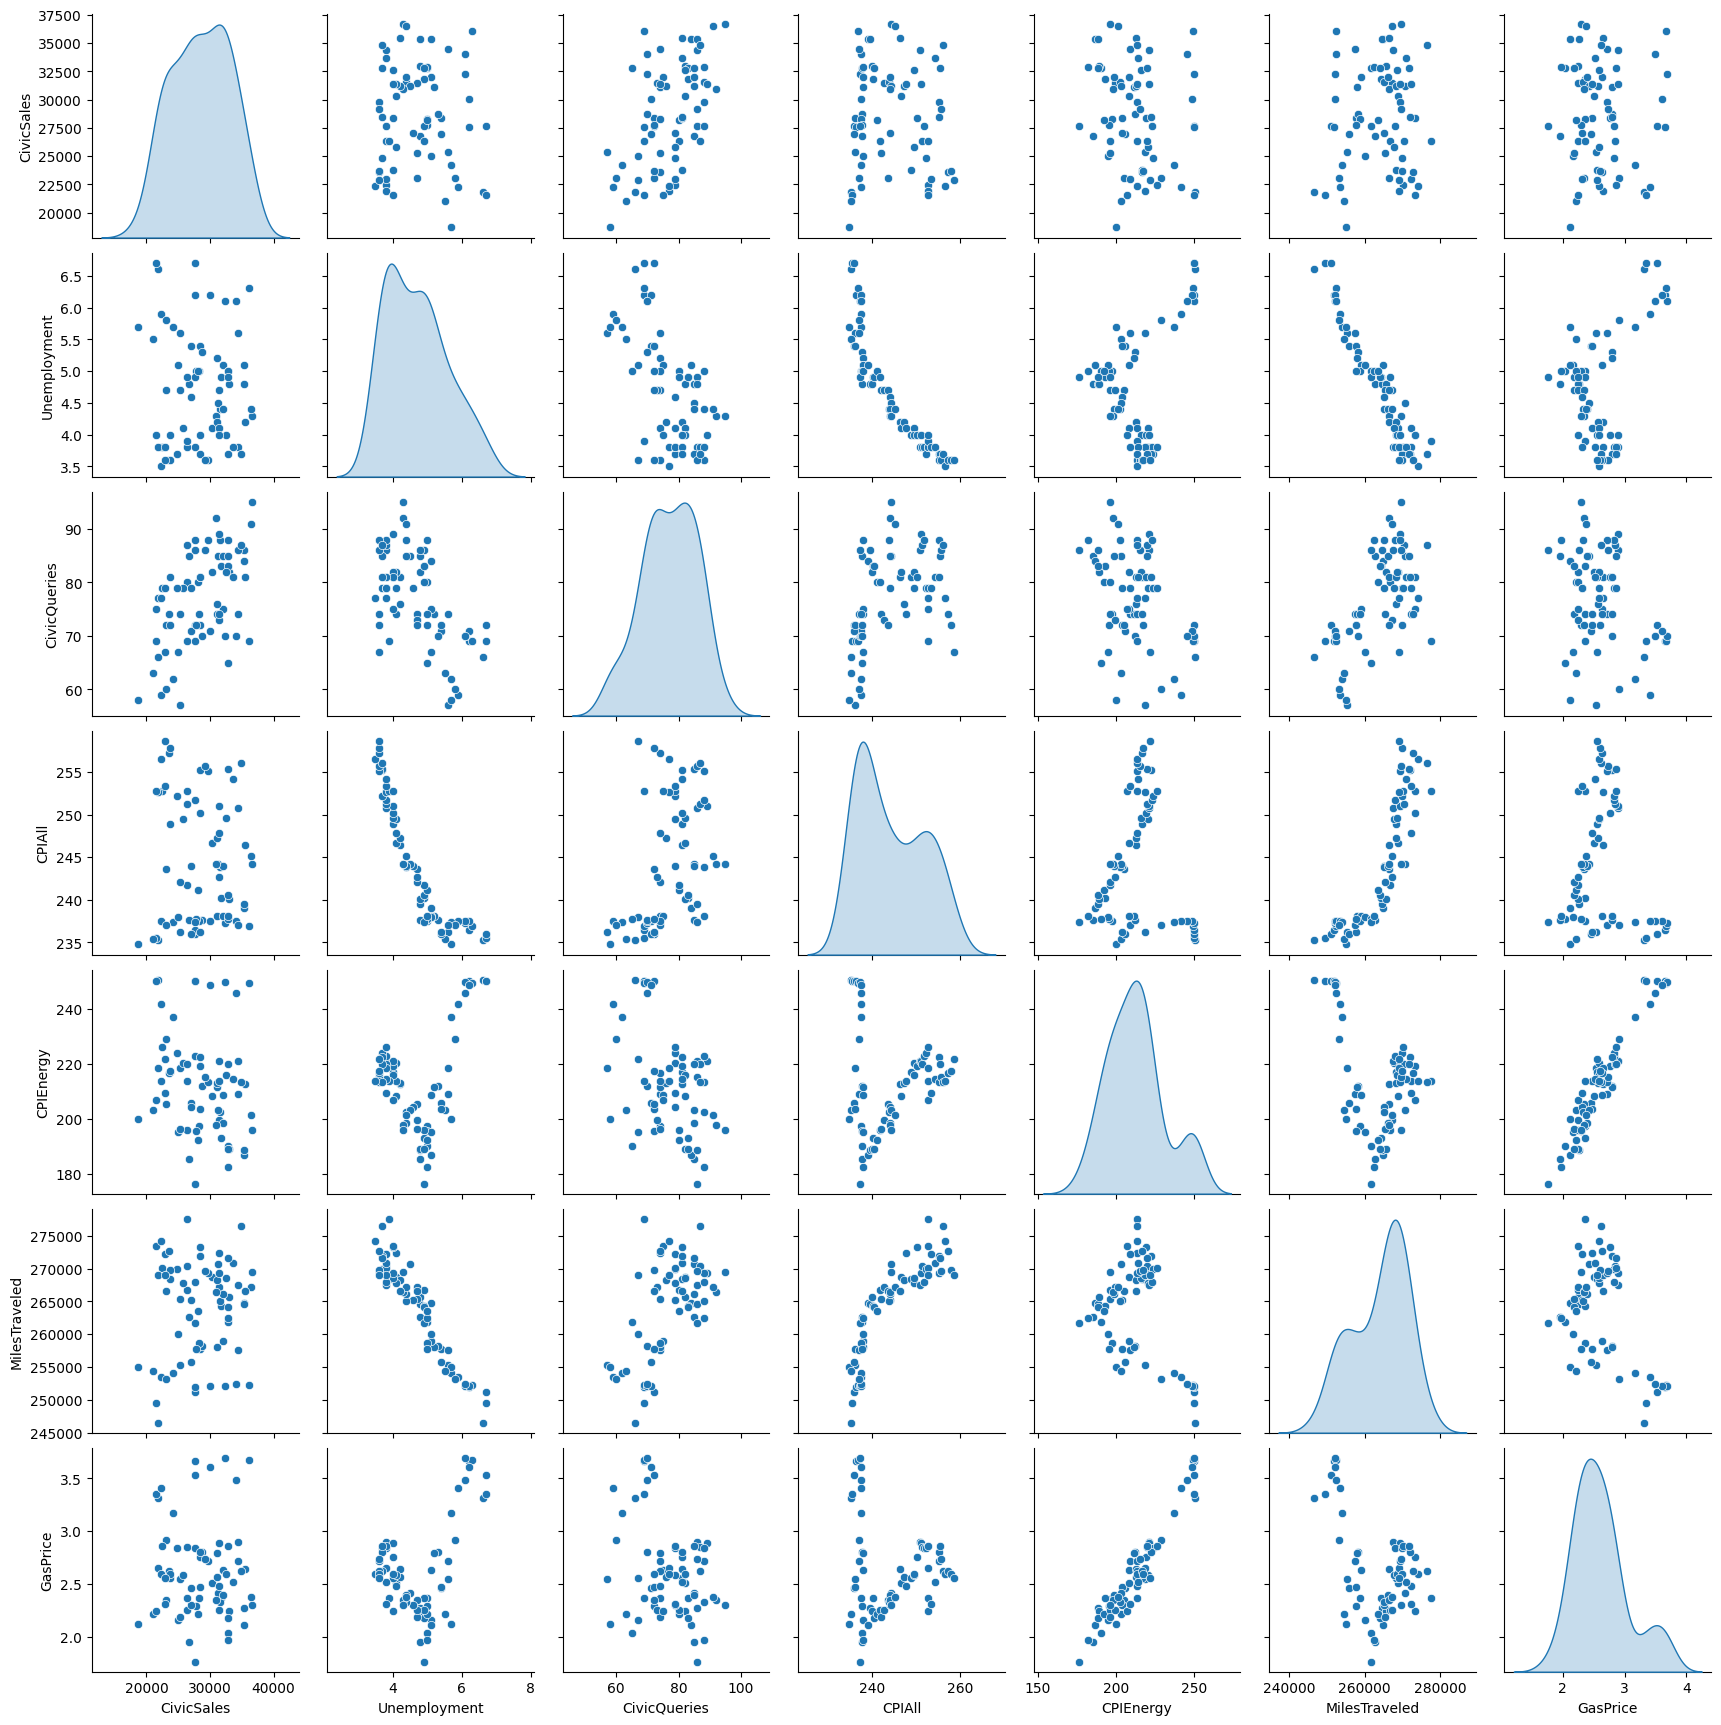

In [270]:
sns.pairplot(train_data_gas.iloc[:,3:10],diag_kind='kde') # try diag_kind='kde' for kernel density estimate (represents the data using a continuous probability density curve )

### Explanation d
While I chose Gas Prices as an additional predictor because I thought rising fuel costs could make efficient cars like the Civic more desirable. However, the results show that gas prices did not improve predictive accuracy. The test R2 fell from 0.39 to 0.05, and OSR2 dropped from 0.84 to 0.75.The scatterplot of CivicSales vs GasPrice also indicates a weak and noisy relationship. 
In regression, Gas Prices were not too statistically significant, suggesting that Gas Prices do not independently drive Civic sales. 

In summary GasPrice did not add predictive value the final model in c.



## Summary of Findings

This homework analyzed monthly Honda Civic sales using linear regression models. Key findings include:

- **Variable Selection and Model Building**: Through iterative testing, multicollinearity assessment (VIF), and feature selection, the optimal subset of predictors was identified as CivicQueries, CPIAll, and MilesTraveled for the basic model (R² = 0.405). Incorporating seasonality via MonthFactor (dummy variables) dramatically improved performance (R² = 0.765).

- **Final Model**: The best model combines CivicQueries, MonthFactor, CPIAll, and MilesTraveled, achieving strong in-sample fit (R² = 0.759) and excellent out-of-sample generalization (OSR² = 0.843), reducing prediction error by 84% compared to a naive mean baseline.

- **Seasonality Impact**: Adding monthly dummies captured periodic sales patterns, with May showing the highest sales relative to April (baseline), and January the lowest. This highlights the importance of temporal effects in demand forecasting.

- **Additional Feature Testing**: Gas prices were hypothesized to boost demand for fuel-efficient vehicles but failed to add predictive value, as evidenced by degraded test performance (R² dropped to 0.05, OSR² to 0.75) and lack of statistical significance.

Overall, the analysis demonstrates effective use of statistical techniques for model refinement, emphasizing the value of seasonality and economic indicators in predicting automotive sales.